# RandOpt on Wordle (Gemma 3 1B) — Direct Comparison with REINFORCE

Tests the **neural thickets** hypothesis: can random search match
gradient-based REINFORCE on the **exact same** Wordle setup?

Matched to `week12_reinforce_gemma.ipynb`:
- Same model: `google/gemma-3-1b-it` (frozen) + trainable linear head
- Same vocab: 32 words
- Same environment: `target_pool=list(policy.words)`
- Same eval function: `evaluate_wordle_lm_policy`
- Same budget: ~640 training episodes
- Same plot layout

## 1. Imports and device

In [1]:
try:
    from google.colab import userdata
    import os
    os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
    print("HF token set.")
except Exception:
    pass

HF token set.


In [3]:
import copy
import importlib
import os
import random
import re
import sys
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

_here = Path.cwd().resolve()
ROOT = _here.parent if _here.name == "notebooks" else _here
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

import wordle_env
from wordle_env import WordleEnvironmentWrapper, WordleState
from wordle_gpt2_policy import WordleGPT2Policy, TRANSFORMERS_AVAILABLE

import wordle_reinforce_lm
importlib.reload(wordle_reinforce_lm)
from wordle_reinforce_lm import evaluate_wordle_lm_policy

if not TRANSFORMERS_AVAILABLE:
    raise ImportError("pip install transformers")


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    mps = getattr(torch.backends, "mps", None)
    if mps is not None and mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def default_model_load_kwargs(device: torch.device) -> dict:
    if device.type != "cuda":
        return {}
    if torch.cuda.is_bf16_supported():
        return {"torch_dtype": torch.bfloat16}
    return {"torch_dtype": torch.float16}


device = choose_device()
print("device:", device)
if device.type == "cpu":
    print("⚠ CPU detected — this will be very slow. Switch to GPU runtime.")

device: cuda


## 2. Patch `wordle_env` to support `target_pool`

The REINFORCE notebook uses `load_wordle_environment(..., target_pool=list(policy.words))`
but our `wordle_env.py` doesn't have that parameter. This cell adds it
by monkey-patching `__init__` and `reset` so the env draws targets from
a custom word list — functionally identical to what REINFORCE uses.

In [4]:
import random as _random

_orig_init = WordleEnvironmentWrapper.__init__
_orig_reset = WordleEnvironmentWrapper.reset


def _patched_init(self, num_episodes=100, max_turns=6, seed=None,
                  use_prime_intellect=True, target_pool=None):
    _orig_init(self, num_episodes=num_episodes, max_turns=max_turns,
               seed=seed, use_prime_intellect=use_prime_intellect)
    self.target_pool = target_pool


def _patched_reset(self):
    if self.target_pool is not None and self.prime_env is None:
        self.current_state = WordleState(
            conversation_history="Guess a 5-letter word. You have 6 attempts.",
            turn_number=0,
            game_complete=False,
            target_word=_random.choice(self.target_pool),
        )
        return self.current_state
    return _orig_reset(self)


WordleEnvironmentWrapper.__init__ = _patched_init
WordleEnvironmentWrapper.reset = _patched_reset

print("Patched WordleEnvironmentWrapper with target_pool support.")

Patched WordleEnvironmentWrapper with target_pool support.


## 3. Config (matches REINFORCE `gemma_full`)

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Model (identical to REINFORCE) ──
MODEL_NAME = "google/gemma-3-1b-it"
USE_PRIME_TARGETS = False
RICHER_PROMPT = True
USE_CHAT_TEMPLATE = True
CHAT_GENERATION_PROMPT = True
MAX_PROMPT_LENGTH = 512
MAX_VOCAB = 32
USE_LORA = False
LORA_R = 4
MAX_TURNS = 6

# ── Environment (identical to REINFORCE) ──
NUM_TRAIN_EXAMPLES = 2000
NUM_EVAL_EXAMPLES = 20

# ── Budget matching ──
# REINFORCE: 40 iterations × 16 episodes/iter = 640 episodes
REINFORCE_ITERS = 40
REINFORCE_EPS_PER_ITER = 16
REINFORCE_BUDGET = REINFORCE_ITERS * REINFORCE_EPS_PER_ITER  # 640

RANDOPT_EVAL_EPS = 4
RANDOPT_STEPS = REINFORCE_BUDGET // RANDOPT_EVAL_EPS  # 160
RANDOPT_SIGMA = 0.02

# ── Eval (identical to REINFORCE) ──
EVAL_EVERY = 20
EVAL_N_EPISODES = 24  # same as REINFORCE eval_n_episodes

MODEL_LOAD_KWARGS = default_model_load_kwargs(device)

print(f"Model: {MODEL_NAME} | vocab: {MAX_VOCAB} actions")
print(f"REINFORCE budget: {REINFORCE_BUDGET} episodes ({REINFORCE_ITERS} iters × {REINFORCE_EPS_PER_ITER} eps)")
print(f"RandOpt budget:   {RANDOPT_STEPS * RANDOPT_EVAL_EPS} episodes ({RANDOPT_STEPS} steps × {RANDOPT_EVAL_EPS} eps)")
print(f"Eval: every {EVAL_EVERY} steps, {EVAL_N_EPISODES} episodes (same as REINFORCE)")

Model: google/gemma-3-1b-it | vocab: 32 actions
REINFORCE budget: 640 episodes (40 iters × 16 eps)
RandOpt budget:   640 episodes (160 steps × 4 eps)
Eval: every 20 steps, 24 episodes (same as REINFORCE)


## 4. Policy and environment (same as REINFORCE §3)

Build policy first, then `target_pool=list(policy.words)` — secrets are
drawn only from the policy's 32-word action set, so every episode is solvable.

In [6]:
print("Loading model...")
policy = WordleGPT2Policy(
    model_name=MODEL_NAME,
    use_prime_targets=USE_PRIME_TARGETS,
    max_vocab_size=MAX_VOCAB,
    max_prompt_length=MAX_PROMPT_LENGTH,
    include_mock_targets_in_vocab=True,
    richer_prompt=RICHER_PROMPT,
    use_chat_template=USE_CHAT_TEMPLATE,
    chat_generation_prompt=CHAT_GENERATION_PROMPT,
    use_lora=USE_LORA,
    lora_r=LORA_R,
    model_kwargs=MODEL_LOAD_KWARGS,
).to(device)
print(f"Policy loaded. action_dim={policy.action_dim}")
print(f"Words: {list(policy.words)[:10]}... ({len(policy.words)} total)")

# ── Environment with target_pool (same as REINFORCE §3) ──
env = WordleEnvironmentWrapper(
    num_episodes=NUM_TRAIN_EXAMPLES,
    max_turns=MAX_TURNS,
    use_prime_intellect=False,
    target_pool=list(policy.words),
)

# Verify targets come from policy words
test_targets = [env.reset().target_word for _ in range(20)]
assert all(t in policy.words for t in test_targets), "Target not in policy.words!"
print(f"Verified: targets drawn from policy.words ({len(policy.words)} words)")
print(f"Sample targets: {test_targets[:5]}")

trainable = policy.count_trainable_parameters()
total = policy.count_parameters()
print(f"Trainable: {trainable:,} / {total:,}")

Loading model...


config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Policy loaded. action_dim=32
Words: ['CRANE', 'SLATE', 'TRACE', 'AUDIO', 'PLANT', 'HEART', 'LIGHT', 'DREAM', 'ABOUT', 'ABOVE']... (32 total)
[OK] Mock Wordle environment (Prime Intellect disabled; targets from MOCK_WORDLE_TARGETS).
Verified: targets drawn from policy.words (32 words)
Sample targets: ['DREAM', 'SLATE', 'AGAIN', 'ADULT', 'ADOPT']
Trainable: 36,896 / 999,922,848


## 5. Helpers

In [7]:
def _trainable_params(p):
    return [param for param in p.parameters() if param.requires_grad]


def get_param_vector(p) -> torch.Tensor:
    return torch.cat([param.data.view(-1).detach().cpu()
                      for param in _trainable_params(p)])


def set_param_vector(p, vec: torch.Tensor) -> None:
    vec = vec.to(device)
    offset = 0
    for param in _trainable_params(p):
        n = param.numel()
        param.data.copy_(vec[offset : offset + n].view_as(param))
        offset += n

## 6. Initial eval (baseline)

In [8]:
print("Running initial eval...")
init_r, init_s, init_t = evaluate_wordle_lm_policy(
    policy, env, n_episodes=EVAL_N_EPISODES, max_turns=MAX_TURNS, deterministic=True,
)
print(f"Initial — reward: {init_r:.3f}  success: {init_s:.1%}  turns: {init_t:.2f}")

Running initial eval...
Initial — reward: 1.263  success: 16.7%  turns: 5.71


In [10]:
## 6b. Warm-start (identical to REINFORCE §4)

from wordle_gpt2_warmstart import supervised_warm_start_wordle

WARM_START_STEPS = 400    # same as REINFORCE gemma_full
WARM_START_LR = 1e-4      # same as REINFORCE
WARM_START_FEEDBACK_CONSISTENT = True   # same as REINFORCE
WARM_START_BATCH_SIZE = 8               # same as REINFORCE

if WARM_START_STEPS > 0:
    ws = supervised_warm_start_wordle(
        policy,
        env,
        n_steps=WARM_START_STEPS,
        lr=WARM_START_LR,
        max_turns=MAX_TURNS,
        device=device,
        seed=SEED,
        verbose=True,
        feedback_consistent_random=WARM_START_FEEDBACK_CONSISTENT,
        batch_size=WARM_START_BATCH_SIZE,
    )
    print("warm-start last loss:", ws["loss"][-1] if ws["loss"] else None)
    print(
        f"  (feedback_consistent_random={WARM_START_FEEDBACK_CONSISTENT}, "
        f"batch_size={WARM_START_BATCH_SIZE}; matched to REINFORCE)"
    )

    # Post-warm-start eval (same as REINFORCE does)
    ws_r, ws_s, ws_t = evaluate_wordle_lm_policy(
        policy, env, n_episodes=EVAL_N_EPISODES, max_turns=MAX_TURNS, deterministic=True,
    )
    print(
        f"Post-warm-start eval ({EVAL_N_EPISODES} eps): "
        f"success={ws_s:.1%}  reward={ws_r:.3f}  turns={ws_t:.2f}"
    )
else:
    print("Skipping warm-start.")

  warm-start 80/400 | loss=4.0553 | opt_steps=10 | bs=8 | skipped=0
  warm-start 160/400 | loss=4.1232 | opt_steps=20 | bs=8 | skipped=0
  warm-start 240/400 | loss=3.9848 | opt_steps=30 | bs=8 | skipped=0
  warm-start 320/400 | loss=3.9385 | opt_steps=40 | bs=8 | skipped=0
  warm-start 400/400 | loss=3.8939 | opt_steps=50 | bs=8 | skipped=0
warm-start last loss: 3.5887680053710938
  (feedback_consistent_random=True, batch_size=8; matched to REINFORCE)
Post-warm-start eval (24 eps): success=16.7%  reward=1.429  turns=5.96


## 7. RandOpt training

No warm-start, no gradients. Random perturbations of the head weights,
keep the best. Budget-matched to REINFORCE at 640 episodes.

Uses `evaluate_wordle_lm_policy` — the same eval function as REINFORCE —
for both candidate selection and periodic evaluation.

In [11]:
original_vec = get_param_vector(policy)
best_vec = original_vec.clone()

# ── History (same keys as REINFORCE for plot compatibility) ──
history = {
    "train_iter": [],
    "mean_return": [],
    "param_drift": [],
    "batch_return_std": [],
    "iteration": [],
    "eval_return": [],
    "eval_success": [],
    "eval_turns": [],
}

# Eval starting point
set_param_vector(policy, best_vec)
best_r, best_s, _ = evaluate_wordle_lm_policy(
    policy, env, n_episodes=RANDOPT_EVAL_EPS, max_turns=MAX_TURNS, deterministic=True,
)
best_reward = best_r

print(f"Starting: reward={best_reward:.3f}")
print(f"Running {RANDOPT_STEPS} steps...")
print()

t0 = time.time()
n_accepted = 0

for step in range(1, RANDOPT_STEPS + 1):
    noise = torch.randn_like(best_vec) * RANDOPT_SIGMA
    cand_vec = best_vec + noise
    set_param_vector(policy, cand_vec)

    cand_r, cand_s, _ = evaluate_wordle_lm_policy(
        policy, env, n_episodes=RANDOPT_EVAL_EPS, max_turns=MAX_TURNS, deterministic=True,
    )

    if cand_r > best_reward:
        best_reward = cand_r
        best_vec = cand_vec.clone()
        n_accepted += 1

    drift = torch.norm(best_vec - original_vec).item()
    history["train_iter"].append(step)
    history["mean_return"].append(best_reward)
    history["param_drift"].append(drift)
    history["batch_return_std"].append(0.0)

    # Periodic eval (same function + episodes as REINFORCE)
    if step % EVAL_EVERY == 0 or step == RANDOPT_STEPS:
        set_param_vector(policy, best_vec)
        ev_r, ev_s, ev_t = evaluate_wordle_lm_policy(
            policy, env, n_episodes=EVAL_N_EPISODES, max_turns=MAX_TURNS, deterministic=True,
        )
        history["iteration"].append(step)
        history["eval_return"].append(ev_r)
        history["eval_success"].append(ev_s)
        history["eval_turns"].append(ev_t)

        print(
            f"Step {step:3d}/{RANDOPT_STEPS} | "
            f"best_reward: {best_reward:.3f} | "
            f"eval — success: {ev_s:.1%}  reward: {ev_r:.3f}  turns: {ev_t:.2f} | "
            f"accepted: {n_accepted}/{step} | "
            f"‖Δθ‖: {drift:.4f} | "
            f"{time.time()-t0:.0f}s"
        )
    elif step % 40 == 0:
        print(
            f"Step {step:3d}/{RANDOPT_STEPS} | "
            f"best_reward: {best_reward:.3f} | "
            f"accepted: {n_accepted}/{step} | "
            f"{time.time()-t0:.0f}s"
        )

set_param_vector(policy, best_vec)
print(f"\nDone in {time.time()-t0:.0f}s.")
print(f"Accepted: {n_accepted}/{RANDOPT_STEPS} ({n_accepted/RANDOPT_STEPS:.1%})")

Starting: reward=1.546
Running 160 steps...

Step  20/160 | best_reward: 1.759 | eval — success: 33.3%  reward: 1.566  turns: 5.38 | accepted: 3/20 | ‖Δθ‖: 6.6391 | 247s
Step  40/160 | best_reward: 1.786 | eval — success: 33.3%  reward: 1.469  turns: 5.12 | accepted: 4/40 | ‖Δθ‖: 7.6743 | 504s
Step  60/160 | best_reward: 2.052 | eval — success: 16.7%  reward: 1.349  turns: 5.62 | accepted: 5/60 | ‖Δθ‖: 8.5701 | 755s
Step  80/160 | best_reward: 2.052 | eval — success: 16.7%  reward: 1.392  turns: 5.46 | accepted: 5/80 | ‖Δθ‖: 8.5701 | 1004s
Step 100/160 | best_reward: 2.052 | eval — success: 16.7%  reward: 1.344  turns: 5.67 | accepted: 5/100 | ‖Δθ‖: 8.5701 | 1260s
Step 120/160 | best_reward: 2.052 | eval — success: 16.7%  reward: 1.331  turns: 5.38 | accepted: 5/120 | ‖Δθ‖: 8.5701 | 1507s
Step 140/160 | best_reward: 2.052 | eval — success: 33.3%  reward: 1.546  turns: 5.04 | accepted: 5/140 | ‖Δθ‖: 8.5701 | 1748s
Step 160/160 | best_reward: 2.070 | eval — success: 16.7%  reward: 1.328 

## 8. Final greedy eval (same as REINFORCE §6a)

In [12]:
mean_r, success, mean_turns = evaluate_wordle_lm_policy(
    policy, env, n_episodes=EVAL_N_EPISODES, max_turns=MAX_TURNS, deterministic=True,
)
print(f"Final greedy eval — mean return: {mean_r:.3f}  success: {success:.1%}  mean turns: {mean_turns:.2f}")

Final greedy eval — mean return: 1.503  success: 25.0%  mean turns: 5.58


## 9. Plots (same 2×3 layout as REINFORCE §6b)

Put these side-by-side with the REINFORCE plots for direct visual comparison.

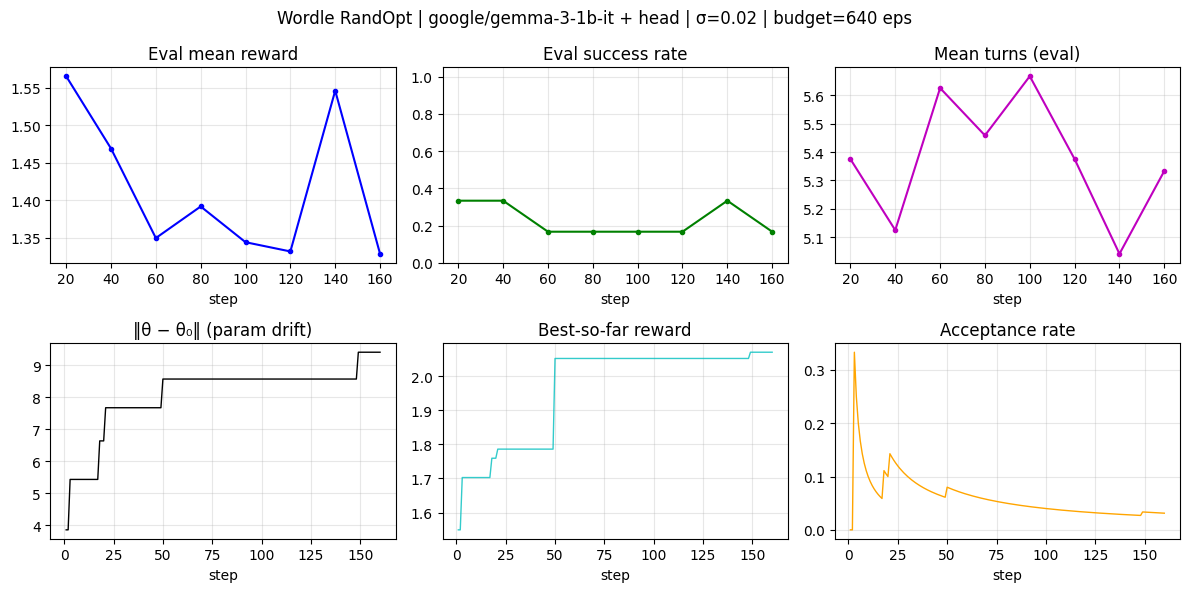

In [13]:
it = history["iteration"]
ti = history["train_iter"]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))

# ── Row 1: Eval (same as REINFORCE) ──
if it and history["eval_return"]:
    axes[0, 0].plot(it, history["eval_return"], "b-o", ms=3)
axes[0, 0].set_title("Eval mean reward")
axes[0, 0].set_xlabel("step")
axes[0, 0].grid(True, alpha=0.3)

if it and history["eval_success"]:
    axes[0, 1].plot(it, history["eval_success"], "g-o", ms=3)
axes[0, 1].set_title("Eval success rate")
axes[0, 1].set_xlabel("step")
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].grid(True, alpha=0.3)

if it and history["eval_turns"]:
    axes[0, 2].plot(it, history["eval_turns"], "m-o", ms=3)
axes[0, 2].set_title("Mean turns (eval)")
axes[0, 2].set_xlabel("step")
axes[0, 2].grid(True, alpha=0.3)

# ── Row 2: Diagnostics ──
if ti and history["param_drift"]:
    axes[1, 0].plot(ti, history["param_drift"], "k-", lw=1)
axes[1, 0].set_title("‖θ − θ₀‖ (param drift)")
axes[1, 0].set_xlabel("step")
axes[1, 0].grid(True, alpha=0.3)

if ti and history["mean_return"]:
    axes[1, 1].plot(ti, history["mean_return"], "c-", lw=1, alpha=0.8)
axes[1, 1].set_title("Best-so-far reward")
axes[1, 1].set_xlabel("step")
axes[1, 1].grid(True, alpha=0.3)

# Acceptance rate (replaces batch_return_std)
if ti:
    acc_rate = []
    running = 0
    prev = history["mean_return"][0]
    for i, r in enumerate(history["mean_return"]):
        if r > prev:
            running += 1
        prev = r
        acc_rate.append(running / (i + 1))
    axes[1, 2].plot(ti, acc_rate, "orange", lw=1)
axes[1, 2].set_title("Acceptance rate")
axes[1, 2].set_xlabel("step")
axes[1, 2].grid(True, alpha=0.3)

plt.suptitle(f"Wordle RandOpt | {MODEL_NAME} + head | σ={RANDOPT_SIGMA} | budget={RANDOPT_STEPS*RANDOPT_EVAL_EPS} eps")
plt.tight_layout()
plt.show()